✅ Model and vectorizer loaded!


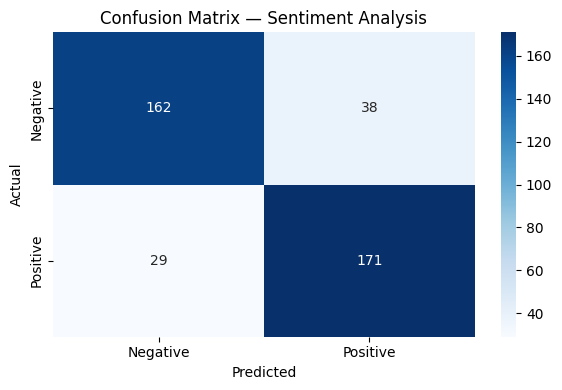

✅ Confusion matrix saved!

       🎬 LIVE SENTIMENT PREDICTIONS

📝 Review   : This movie was absolutely amazing! Great acting and sto...
🎯 Sentiment: 😊 POSITIVE

📝 Review   : Terrible film. Complete waste of time. Very disappointi...
🎯 Sentiment: 😞 NEGATIVE

📝 Review   : The plot was interesting but the acting was mediocre....
🎯 Sentiment: 😞 NEGATIVE

📝 Review   : One of the best movies I have ever seen. Highly recomme...
🎯 Sentiment: 😊 POSITIVE

📝 Review   : Boring and predictable. I fell asleep halfway through....
🎯 Sentiment: 😞 NEGATIVE

       📊 FINAL MODEL SUMMARY
  ✅ Accuracy      : 0.8325
  ✅ Test samples  : 400
  ✅ Dataset       : NLTK Movie Reviews
  ✅ Features      : TF-IDF (10K features)

🎉 All 3 Notebooks Complete!


In [1]:
# ============================================================
# 📈 NOTEBOOK 3 — Evaluation & Live Predictions
# ============================================================

import os
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve,
                              auc, classification_report)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import warnings
warnings.filterwarnings('ignore')

# ── Setup Paths ──────────────────────────────────────────────
BASE_DIR    = os.path.expanduser('~/sentiment-analysis-nlp')
DATA_DIR    = os.path.join(BASE_DIR, 'data')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')

# ── Load Model & Vectorizer ──────────────────────────────────
with open(os.path.join(MODELS_DIR, 'best_model.pkl'), 'rb') as f:
    model = pickle.load(f)

with open(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'), 'rb') as f:
    tfidf = pickle.load(f)

print("✅ Model and vectorizer loaded!")

# ── Load Data ────────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_reviews.csv')).dropna()
X  = tfidf.transform(df['clean_text'])
y  = df['label']

from sklearn.model_selection import train_test_split
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

y_pred = model.predict(X_test)

# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Sentiment Analysis')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'))
plt.show()
print("✅ Confusion matrix saved!")

# ── Live Predictions ─────────────────────────────────────────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text   = text.lower()
    text   = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t)
              for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

test_reviews = [
    "This movie was absolutely amazing! Great acting and storyline.",
    "Terrible film. Complete waste of time. Very disappointing.",
    "The plot was interesting but the acting was mediocre.",
    "One of the best movies I have ever seen. Highly recommend!",
    "Boring and predictable. I fell asleep halfway through."
]

print("\n" + "="*55)
print("       🎬 LIVE SENTIMENT PREDICTIONS")
print("="*55)
for review in test_reviews:
    cleaned   = clean_text(review)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    sentiment  = "😊 POSITIVE" if prediction == 1 else "😞 NEGATIVE"
    print(f"\n📝 Review   : {review[:55]}...")
    print(f"🎯 Sentiment: {sentiment}")

# ── Final Summary ────────────────────────────────────────────
from sklearn.metrics import accuracy_score
print("\n" + "="*45)
print("       📊 FINAL MODEL SUMMARY")
print("="*45)
print(f"  ✅ Accuracy      : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ✅ Test samples  : {len(y_test)}")
print(f"  ✅ Dataset       : NLTK Movie Reviews")
print(f"  ✅ Features      : TF-IDF (10K features)")
print("="*45)
print("\n🎉 All 3 Notebooks Complete!")